In [1]:
from groq import Groq
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_core.messages.utils import trim_messages,count_tokens_approximately
from langchain_groq import ChatGroq

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(model="qwen/qwen3-32b", temperature=0.7, reasoning_format="hidden")

In [4]:
MAX_TOKENS = 150

In [5]:
def call_model(state: MessagesState):

    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [7]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

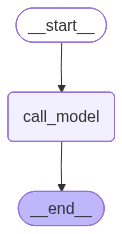

In [8]:
graph

In [9]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Ankit."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is Ankit.


'Hello Ankit! Nice to meet you! How can I assist you today? 😊'

In [10]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 41
Hi, my name is Ankit.
Hello Ankit! Nice to meet you! How can I assist you today? 😊
I am learning LangGraph.


'That\'s exciting, Ankit! LangGraph is a powerful framework for building state-of-the-art LLM applications using **LangChain** and **GraphLang**. It allows you to define complex workflows as **state machines** (e.g., for chatbots, RAG systems, or multi-step agents). Here\'s a quick overview to help you get started:\n\n---\n\n### **Key Concepts in LangGraph**\n1. **Nodes**: Represent functions (LLM calls, tools, or custom logic) in your workflow.\n2. **Edges**: Define transitions between nodes based on conditions or outputs.\n3. **State**: Stores the context (e.g., chat history, intermediate results) as the graph executes.\n4. **Graph**: Combines nodes and edges into a directed acyclic graph (DAG) or state machine.\n\n---\n\n### **Getting Started**\n1. **Install LangGraph**:\n   ```bash\n   pip install langgraph\n   ```\n2. **Basic Example** (from the LangChain docs):\n   ```python\n   from langgraph.graph import Graph\n   from langchain_openai import ChatOpenAI\n\n   def add(a, b):\n  

In [11]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


'Short-term memory (STM) is a cognitive system responsible for temporarily holding and managing information required for immediate use. It acts as a mental workspace that allows us to process and manipulate data while performing tasks like reasoning, learning, and comprehension. Below is a structured explanation of STM, its components, and its role in cognition:\n\n---\n\n### **Key Features of Short-Term Memory**\n1. **Duration**:  \n   - STM holds information for **15–30 seconds** unless actively maintained. For example, if you’re given a phone number to remember, it will fade quickly unless you rehearse it.\n\n2. **Capacity**:  \n   - Classic theory (Miller, 1956) suggests STM can hold **7±2 "chunks"** of information. A chunk is a unit of information, such as a number, word, or concept.  \n   - Modern research (e.g., Cowan, 2001) proposes a lower bound of **4±1 chunks**, especially for complex tasks. For instance, remembering a sequence of letters might require grouping them into few

In [12]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


'I don’t have access to personal information about you unless you provide it directly. Could you please share your name with me?'

In [13]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Ankit.
------------------------------------------------------------------------------------------------------------------------
Hello Ankit! Nice to meet you! How can I assist you today? 😊
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That's exciting, Ankit! LangGraph is a powerful framework for building state-of-the-art LLM applications using **LangChain** and **GraphLang**. It allows you to define complex workflows as **state machines** (e.g., for chatbots, RAG systems, or multi-step agents). Here's a quick overview to help you get started:

---

### **Key Concepts in LangGraph**
1. **Nodes**: Represent functions (LLM calls, tools, or custom logic) in your workflow.
2. **Edges**: Define transitions between nodes based on conditions or outputs.
3. **Sta